# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [35]:
!git clone https://github.com/ds4e/undergrad_ml_assignments.git

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Question 1:**

1) Regular linear models assume the output is continuous and can take any value, which doesn’t work well for things like probabilities. GLMs and logistic regression fix this by applying an activation function (like the sigmoid) to map predictions into a valid range (like 0–1). A latent variable model is like  having an underlying linear relationship, but then transforming it so it fits the type of data we actually observe. The advantage is they handle non-normal outcomes (like binary or categorical data) and give interpretable probabilities.

2) Cross-entropy measures how far the predicted probabilities are from the true labels. It heavily penalizes confident but wrong predictions, which is exactly what we want in classification. Also, it comes from probability theory (maximum likelihood), so minimizing it gives the best-fitting probabilistic model.

3) This is true but context matters. It’s linear in the inputs before applying the activation function (the log-odds are a linear combination of features). However, the final output is nonlinear because of the sigmoid function.

4) This is false. It’s specifically designed for classification. It outputs probabilities, and we convert those into class labels using a threshold (like 0.5).

5) Not directly. In logistic regression, coefficients represent the change in log-odds, not the raw predicted probability. So a 1-unit increase in a feature changes the log-odds by the coefficient, which then affects the probability in a nonlinear way.

6) This is false. Logistic regression is still linear in the features. The nonlinearity only comes from the sigmoid transformation. So if the relationship between features and outcome is complex, you still need feature engineering (like interactions or polynomial terms).

7) This is false because it depends on the problem. Logistic regression is better for classification tasks (binary or categorical outcomes), while linear regression is better for predicting continuous values. Therefore one isn’t universally better, they’re used for different types of problems.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [36]:
# Question 2 Part 1

import pandas as pd

df = pd.read_csv('./undergrad_ml_assignments/data/data.csv', sep=';')

df = df[['Debtor',
         'Tuition fees up to date',
         'Scholarship holder',
         'Age at enrollment',
         'Curricular units 1st sem (approved)',
         'Target']]

print("Missing values before cleaning:\n", df.isna().sum())

df = df.dropna()

df['dropout'] = (df['Target'] == 'Dropout').astype(int)

print(df.head())

Missing values before cleaning:
 Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  dropout  
0                                    0   Dropout        1  
1                                    6  Graduate        0  
2                                    0   Dropout        1  
3    

In [37]:
# Question 2 Part 2
from sklearn.linear_model import LogisticRegression

X = df[['Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        'Age at enrollment']]

y = df['dropout']

logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)

coeffs = pd.Series(logit.coef_[0], index=X.columns)
print(coeffs)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


Question 2 Part 2: Debtor status increases dropout risk, while being current on tuition and holding a scholarship reduce it, with tuition status having the strongest effect. Older age at enrollment slightly raises the likelihood of dropout. Overall, staying up to date on tuition clearly lowers dropout risk.

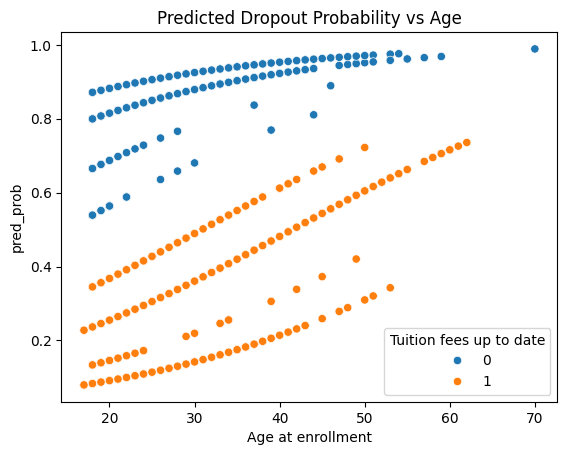

Tuition fees up to date
0    0.860675
1    0.248090
Name: pred_prob, dtype: float64


In [38]:
# Question 2 Part 3
import seaborn as sns
import matplotlib.pyplot as plt

df['pred_prob'] = logit.predict_proba(X)[:, 1]

sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='pred_prob',
    hue='Tuition fees up to date'
)
plt.title("Predicted Dropout Probability vs Age")
plt.show()

avg_effect = df.groupby('Tuition fees up to date')['pred_prob'].mean()
print(avg_effect)

Question 2 Part 3: The plot shows that students current on tuition have much lower dropout rates than those who are not, across all ages. This effect is consistent across age groups, with up to date tuition reducing dropout probability by about 0.61 on average.

In [39]:
# Question 2 Part 4

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = logit.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print("Accuracy:", acc)

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


Question 2 Part 4: The model correctly classifies about 76.2% of students.

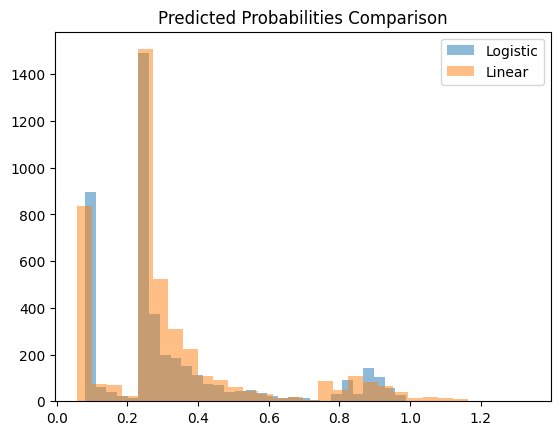

In [40]:
# Question Part 5

from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(X, y)

df['lin_prob'] = lin.predict(X)

plt.hist(df['pred_prob'], bins=30, alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], bins=30, alpha=0.5, label='Linear')
plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()

Question 2 Part 5: The logistic model yields valid probabilities between 0 and 1, while the linear model produces some values above 1. The histogram shows logistic regression provides more realistic, reliable predictions, making it the better choice for modeling dropout probability.

Question 2 Part 6 : Students most at risk are those behind on tuition, in debt, and without scholarships, as these factors raise dropout probability. Schools could support them with financial aid such as payment plans or scholarships and added academic help like advising or tutoring.

In [41]:
# Question 2 Part 7

from sklearn.linear_model import LogisticRegression

X_multi = df[['Debtor',
              'Tuition fees up to date',
              'Curricular units 1st sem (approved)']]

y_multi = df['Target']

multi = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi.fit(X_multi, y_multi)

y_pred_multi = multi.predict(X_multi)

from sklearn.metrics import confusion_matrix
cm_multi = confusion_matrix(y_multi, y_pred_multi)
print(cm_multi)

probs = multi.predict_proba(X_multi)
print(probs[:5])

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Question 2 Part 7: The confusion matrix shows uneven performance across classes, with some misclassified more often. While .predict() does not select all classes equally, .predict_proba() still assigns probabilities to all three classes even when they are not chosen.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [42]:
# Question 3 Part 1

import pandas as pd

df = pd.read_csv('./undergrad_ml_assignments/data/cirrhosis.csv')

df = df[['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']]

print("Missing values before cleaning:\n", df.isna().sum())

df = df.dropna()

print(df.head())


Missing values before cleaning:
 Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64
   Bilirubin Edema             Drug  Stage Status
0       14.5     Y  D-penicillamine    4.0      D
1        1.1     N  D-penicillamine    3.0      C
2        1.4     S  D-penicillamine    4.0      D
3        1.8     S  D-penicillamine    4.0      D
4        3.4     N          Placebo    3.0     CL


In [43]:
# Question 3 Part 2

import pandas as pd
from sklearn.linear_model import LogisticRegression

df['Survived'] = df['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)

X = pd.get_dummies(df[['Edema', 'Drug', 'Bilirubin']], drop_first=True)
y = df['Survived']

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X, y)

coef_table = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': log_model.coef_[0]
})

print(coef_table)
print("Intercept:", log_model.intercept_[0])

       Variable  Coefficient
0     Bilirubin    -0.351424
1       Edema_S    -0.450677
2       Edema_Y    -1.611049
3  Drug_Placebo     0.231225
Intercept: 1.3798277993022918


Question 3 Part 2: Higher bilirubin levels and more severe edema are associated with lower survival, while the placebo shows only a small, relatively weak survival advantage compared to D-penicillamine.

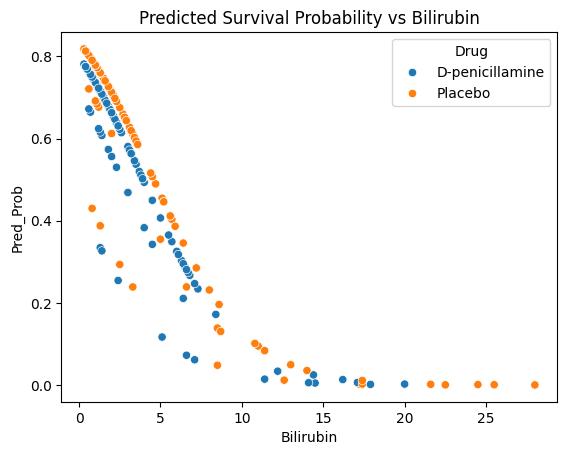

Drug
D-penicillamine    0.590054
Placebo            0.608902
Name: Pred_Prob, dtype: float64
Average difference: 0.01884850103850899


In [44]:
# Question 3 Part 3

import seaborn as sns
import matplotlib.pyplot as plt

df['Pred_Prob'] = log_model.predict_proba(X)[:,1]

sns.scatterplot(data=df, x='Bilirubin', y='Pred_Prob', hue='Drug')
plt.title("Predicted Survival Probability vs Bilirubin")
plt.show()

drug_means = df.groupby('Drug')['Pred_Prob'].mean()
print(drug_means)
print("Average difference:",
      drug_means.iloc[1] - drug_means.iloc[0])

Question 3 Part 3: Survival probability declines as bilirubin rises in both groups. The drug shows no consistent benefit at any level, with substantial overlap between groups. On average, treated patients have slightly lower survival (≈ −0.018), suggesting no meaningful improvement.

In [45]:
# Question 3 Part 4

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = log_model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)


Confusion Matrix:
 [[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


Question 3 Part 4: The model correctly classifies about 73.7% of patients.

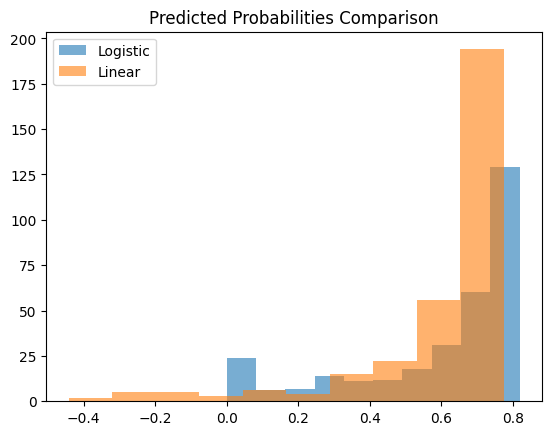

In [46]:
# Question 3 Part 5

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df['Lin_Prob'] = lin_model.predict(X)

plt.hist(df['Pred_Prob'], alpha=0.6, label='Logistic')
plt.hist(df['Lin_Prob'], alpha=0.6, label='Linear')
plt.legend()
plt.title("Predicted Probabilities Comparison")
plt.show()

Question 3 Part 5: Logistic regression yields valid probabilities (0–1), whereas the linear model produces invalid negative values. The histogram shows logistic regression gives more realistic, reliable predictions, making it the better choice for survival probability.

In [47]:
# Question 3 Part 6:

X_stage = pd.get_dummies(df[['Edema', 'Bilirubin']], drop_first=True)
y_stage = df['Stage']

multi_model = LogisticRegression(max_iter=1000, multi_class='multinomial')
multi_model.fit(X_stage, y_stage)

stage_pred = multi_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, stage_pred)
print("Confusion Matrix:\n", cm_stage)

stage_probs = multi_model.predict_proba(X_stage)

print("Predicted Classes:", set(stage_pred))
print("Probability sample:\n", stage_probs[:5])

Confusion Matrix:
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
Predicted Classes: {np.float64(3.0), np.float64(4.0)}
Probability sample:
 [[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Question 3 Part 6: The confusion matrix indicates the model is biased toward higher stages (especially Stages 3 and 4) and rarely predicts lower ones, so .predict() fails to represent all classes. However, .predict_proba() still assigns probabilities to every stage, even if they aren’t selected in the final prediction.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

**I uploaded my written answers to Question 4 in the repository titled "Answers to Question 4 for 05 assignment."**